In [ ]:
import pandas as pd
from collections import defaultdict
from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import numpy as np
import re

candidates = [
    Path('../data/nba_data.csv')
]

data_path = None
for p in candidates:
    if p.exists():
        data_path = p
        break

# If still not found, try to locate anywhere under the current working directory
if data_path is None:
    matches = list(Path.cwd().rglob('./data/nba_data.csv'))
    if matches:
        data_path = matches[0]

if data_path is None:
    raise FileNotFoundError(
        "nba_data.csv not found. Checked candidates: "
        + ", ".join(str(p) for p in candidates)
        + f". Current working directory: {Path.cwd()}. "
        "Place the CSV at one of the checked locations or update the path."
    )

# Load the data
df = pd.read_csv(data_path)

# Helper to decide point value from shot-type text or distance
def _determine_point_value_from_type_or_distance(row):
    st = ''
    for col in ('SHOT_TYPE','SHOT_TYPE_DESC','SHOT_ZONE_BASIC','DESCRIPTION'):
        if col in row.index and pd.notna(row[col]):
            st = str(row[col])
            break
    stl = st.lower()
    if '3pt' in stl or '3-pt' in stl or '3 point' in stl or '3pt field' in stl:
        return 3
    if 'free' in stl or 'ft' in stl:
        return 1
    # fallback to shot distance heuristic
    if 'SHOT_DISTANCE' in row.index and pd.notna(row['SHOT_DISTANCE']):
        try:
            d = float(row['SHOT_DISTANCE'])
            return 3 if d >= 23 else 2
        except Exception:
            pass
    return 2

# Unified computation: returns (made_flag:int 0/1, points:int)
def _compute_made_and_points(row):
    # 1) Look for numeric flags that may encode points directly (e.g., 3,2,1)
    for col in ('SHOT_MADE_FLAG','SHOT_MADE','MADE','made','shot_made_flag'):
        if col in row.index and pd.notna(row[col]):
            # try numeric
            try:
                v = float(row[col])
                if v.is_integer():
                    vi = int(v)
                    if vi == 0:
                        return 0, 0
                    if vi in (2, 3):
                        # flag stores point value directly
                        return 1, vi
                    if vi == 1:
                        # ambiguous: treat as made, but determine actual point value from type/distance
                        pts = _determine_point_value_from_type_or_distance(row)
                        return 1, pts
            except Exception:
                pass
            # if not numeric, examine textual value
            s = str(row[col]).strip().lower()
            if s in ('made','made 2','made 3'):
                pts = _determine_point_value_from_type_or_distance(row)
                return 1, pts
            if s in ('miss','missed','0','false','f'):
                return 0, 0
    # 2) Check textual result fields
    for col in ('SHOT_RESULT','shotResult','shot_result','RESULT','DESCRIPTION'):
        if col in row.index and pd.notna(row[col]):
            s = str(row[col]).strip().lower()
            if 'made' in s:
                pts = _determine_point_value_from_type_or_distance(row)
                return 1, pts
            if 'miss' in s or 'missed' in s:
                return 0, 0
    # 3) EVENTMSGTYPE fallback (1 == made)
    if 'EVENTMSGTYPE' in row.index and pd.notna(row['EVENTMSGTYPE']):
        try:
            return (1, _determine_point_value_from_type_or_distance(row)) if int(row['EVENTMSGTYPE']) == 1 else (0, 0)
        except Exception:
            pass
    # Default: not made
    return 0, 0

# Apply the unified logic to produce MADE_FLAG (0/1) and POINTS
made_points = df.apply(_compute_made_and_points, axis=1)
# made_points is a Series of tuples; convert to columns
df['MADE_FLAG'] = [mp[0] for mp in made_points]
# If any row already has a numeric POINTS value that looks correct (>0), prefer it; otherwise use computed
computed_points = [mp[1] for mp in made_points]
if 'POINTS' in df.columns:
    # try to coerce existing points to numeric; replace zeros with computed where appropriate
    existing = pd.to_numeric(df['POINTS'], errors='coerce').fillna(0).astype(int)
    df['POINTS'] = [e if e > 0 else c for e, c in zip(existing.tolist(), computed_points)]
else:
    df['POINTS'] = computed_points

# Ensure SHOT_MADE_FLAG is normalized to 0/1 for downstream code
# If original SHOT_MADE_FLAG contained point-values, overwrite with 0/1
if 'SHOT_MADE_FLAG' in df.columns:
    try:
        shot_flag_numeric = pd.to_numeric(df['SHOT_MADE_FLAG'], errors='coerce')
        df['SHOT_MADE_FLAG'] = shot_flag_numeric.apply(lambda v: 1 if pd.notna(v) and int(v) in (1,2,3) and int(v) > 0 else (1 if str(v).strip().lower() in ('made','true','t','yes') else 0))
    except Exception:
        df['SHOT_MADE_FLAG'] = df['MADE_FLAG']
else:
    df['SHOT_MADE_FLAG'] = df['MADE_FLAG']

# Recompute player aggregates using POINTS and normalized made flag
player_stats = df.groupby('PLAYER_NAME').agg(
    TOTAL_POINTS=('POINTS','sum'),
    TOTAL_ATTEMPTS=('POINTS','count'),
    MAKES=('MADE_FLAG','sum'),
    THREE_PT_ATTEMPTS=('SHOT_TYPE', lambda s: s.astype(str).str.contains('3pt', case=False, na=False).sum())
).reset_index()

player_stats.rename(columns={'PLAYER_NAME':'PLAYER'}, inplace=True)
player_stats['FG_PCT'] = player_stats['MAKES'] / player_stats['TOTAL_ATTEMPTS'] * 100
player_stats['PTS_PER_SHOT'] = player_stats['TOTAL_POINTS'] / player_stats['TOTAL_ATTEMPTS']

# Sort by total points
top_scorers = player_stats.sort_values('TOTAL_POINTS', ascending=False).head(15)





In [ ]:
#Top Yearly Scorers, will show how different players have performed over the years

from pathlib import Path
outdir = Path('../outputs')
outdir.mkdir(parents=True, exist_ok=True)
# Top 10 scorers as an interactive Plotly bar chart
top_10 = top_scorers.head(10)
fig = px.bar(top_10, x='PLAYER', y='TOTAL_POINTS', text='TOTAL_POINTS',
             title='Top 10 Scorers NBA',
             labels={'PLAYER':'Player','TOTAL_POINTS':'Total Points'})
fig.update_traces(textposition='outside')
fig.update_layout(template='plotly_dark', xaxis_tickangle=-45, width=900, height=520, margin=dict(t=60,b=120))
# save interactive HTML and show inline
fig.write_html(str(outdir / 'top10_scorers.html'))
fig.write_image(str(outdir / 'top10_scorers.png'))
fig.show()



Resorting to unclean kill browser.


In [ ]:
from pathlib import Path
outdir = Path('../outputs')
outdir.mkdir(parents=True, exist_ok=True)
# Scatter: Points per shot vs Total points, size by attempts
top_15 = top_scorers.head(15)
fig = px.scatter(top_15, x='PTS_PER_SHOT', y='TOTAL_POINTS', size='TOTAL_ATTEMPTS',
                 hover_name='PLAYER', text='PLAYER',
                 title='Scoring Efficiency vs Volume (Size = Shot Attempts)',
                 labels={'PTS_PER_SHOT':'Points per Shot Attempt','TOTAL_POINTS':'Total Points','TOTAL_ATTEMPTS':'Total Attempts'})
fig.update_traces(marker=dict(opacity=0.7), textposition='top center')
fig.update_layout(template='plotly_dark', width=1000, height=560, margin=dict(t=70,b=80))
# save interactive HTML and show inline
fig.write_html(str(outdir / 'efficiency_vs_volume.html'))
fig.write_image(str(outdir / 'efficiency_vs_volume.png'))
fig.show()

<Figure size 1200x600 with 0 Axes>

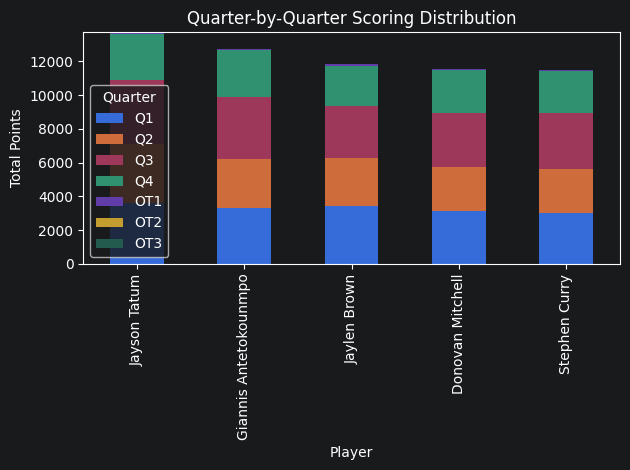

In [ ]:
# Analyze scoring by period
import matplotlib.pyplot as plt

period_stats = df[df['SHOT_MADE_FLAG'] == 1].groupby(['PLAYER_NAME', 'PERIOD']).agg({
    'POINTS': 'sum'
}).unstack().fillna(0)

# Top 5 players quarter breakdown
top_5_players = top_scorers.head(5)['PLAYER'].tolist()
top_period_stats = period_stats.loc[top_5_players]

plt.figure(figsize=(12, 6))
top_period_stats.plot(kind='bar', stacked=True)
plt.xlabel('Player')
plt.ylabel('Total Points')
plt.title('Quarter-by-Quarter Scoring Distribution')
plt.legend(title='Quarter', labels=['Q1', 'Q2', 'Q3', 'Q4', 'OT1', 'OT2', 'OT3'])
plt.tight_layout()
plt.show()

In [ ]:

import plotly.graph_objects as go
from pathlib import Path
outdir = Path('../outputs')
outdir.mkdir(parents=True, exist_ok=True)

# Players to plot (change list as needed)
players_to_plot = ['Stephen Curry', 'Luka Doncic']


def court_shape_list():
    # return a list of Plotly shape dicts approximating key court features
    shapes = []
    # hoop
    shapes.append(dict(type='circle', xref='x', yref='y', x0=-7.5, x1=7.5, y0=-7.5, y1=7.5, line=dict(color='lightgrey', width=1.5)))
    # backboard
    shapes.append(dict(type='line', x0=-30, x1=30, y0=-7.5, y1=-7.5, line=dict(color='lightgrey', width=1)))
    # paint rectangle
    shapes.append(dict(type='rect', x0=-80, x1=80, y0=-47.5, y1=143, line=dict(color='lightgrey', width=1)))
    # 3-pt side lines
    shapes.append(dict(type='line', x0=-220, x1=-220, y0=-47.5, y1=92.5, line=dict(color='lightgrey', width=1)))
    shapes.append(dict(type='line', x0=220, x1=220, y0=-47.5, y1=92.5, line=dict(color='lightgrey', width=1)))
    # approximate 3-pt arc as a circle slice using a full circle for reference (visual only)
    shapes.append(dict(type='circle', xref='x', yref='y', x0=-238, x1=238, y0=-238, y1=238, line=dict(color='lightgrey', width=0.8, dash='dot')))
    return shapes

for player in players_to_plot:
    player_shots = df[df['PLAYER_NAME'] == player]
    if player_shots.empty:
        print(f'No shots found for {player}; skipping')
        continue
    # map made flag to labels for discrete coloring
    made_col = 'SHOT_MADE_FLAG' if 'SHOT_MADE_FLAG' in player_shots.columns else None
    if made_col is not None:
        player_shots = player_shots.copy()
        player_shots['made_label'] = player_shots[made_col].map({1:'Made', 0:'Missed'}).fillna('Unknown')
        color = 'made_label'
        color_map = {'Made':'green','Missed':'red','Unknown':'gray'}
    else:
        color = None
        color_map = None

    fig = px.scatter(player_shots, x='LOC_X', y='LOC_Y', color=color,
                     color_discrete_map=color_map if color_map else None,
                     title=f'Shot Chart: {player} (Green=Made, Red=Missed)',
                     labels={'LOC_X':'Court X Position','LOC_Y':'Court Y Position'},
                     width=760, height=700)
    fig.update_traces(marker=dict(size=6, opacity=0.7))
    # add court shapes
    for s in court_shape_list():
        fig.add_shape(s)
    fig.update_layout(template='plotly_dark', xaxis=dict(visible=False, range=[-250,250]), yaxis=dict(visible=False, range=[-50,500], scaleanchor='x'))
    out_file = outdir / f'shot_chart_{player.replace(' ','_')}.html'
    fig.write_html(str(out_file))
    fig.write_image(str(out_file.with_suffix('.png')))
    print('Wrote:', out_file)
    fig.show()

Wrote: ../outputs/shot_chart_Stephen_Curry.html


Wrote: ../outputs/shot_chart_Luka_Doncic.html


In [ ]:

# 1. Average shot distance change over years
# 2. Top 5 highest 3-pt % shooters with >= 500 attempts

from pathlib import Path
import plotly.express as px
import plotly.graph_objects as go
outdir = Path('../outputs')
outdir.mkdir(parents=True, exist_ok=True)

# Analysis 1: Average shot distance by year
year_col = 'YEAR' if 'YEAR' in df.columns else 'Year'
dist_col = 'shotDistance' if 'shotDistance' in df.columns else 'SHOT_DISTANCE'

if year_col in df.columns and dist_col in df.columns:
    dist_by_year = df.groupby(year_col)[dist_col].mean().reset_index()
    fig1 = px.line(dist_by_year, x=year_col, y=dist_col, title='Average Shot Distance per Year', markers=True)
    fig1.update_layout(template='plotly_dark')
    fig1.write_html(str(outdir / 'avg_shot_distance.html'))
    fig1.write_image(str(outdir / 'avg_shot_distance.png'))
    fig1.show()



In [57]:
# Analysis 2: How does league-wide FG% vary by quarter?
from pathlib import Path
import plotly.express as px
outdir = Path('../outputs')
outdir.mkdir(parents=True, exist_ok=True)

if 'PERIOD' in df.columns and 'SHOT_MADE_FLAG' in df.columns:
    reg = df[df['PERIOD'].between(1, 4)].copy()
    quarter_stats = reg.groupby('PERIOD').agg(
        attempts=('SHOT_MADE_FLAG', 'count'),
        makes=('SHOT_MADE_FLAG', 'sum')
    ).reset_index()
    quarter_stats['FG%'] = quarter_stats['makes'] / quarter_stats['attempts']
    quarter_stats['Quarter'] = quarter_stats['PERIOD'].map({1:'Q1',2:'Q2',3:'Q3',4:'Q4'})

    fig3 = px.bar(quarter_stats, x='Quarter', y='FG%', text_auto='.1%',
                  title='League-Wide FG% by Quarter (2019-2025)',
                  labels={'FG%':'Field Goal %'})
    fig3.update_layout(template='plotly_dark', width=800, height=500)
    fig3.write_html(str(outdir / 'fg_pct_by_quarter.html'))
    fig3.write_image(str(outdir / 'fg_pct_by_quarter.png'))
    fig3.show()
